# Visualization timeseries
간단한 시각화와 날짜/시간 처리를 익힌다.
데이터를 빠르게 확인하고 흐름을 파악하는 용도로 사용한다.
(추후 Matplotlib에서 더 세밀한 시각화 방법을 학습한다.)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Windows 기준 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐
plt.rc('axes', unicode_minus=False)

## 선 그래프
 - 시간의 흐름이나 순서에 따른 변화를 볼 때 자주 사용
 - 월별 매출 추이처럼 증가/감소 흐름을 빠르게 확인 가능

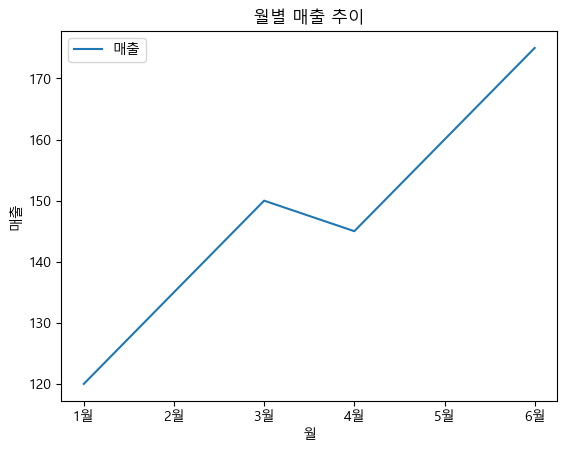

In [3]:
sales = pd.DataFrame({
    '월' : ['1월','2월','3월','4월','5월','6월'],
    '매출' : [120,135,150,145,160,175]
})

# Pandas의 plot: 그래프의 기본 구조를 빠르게 생성 (단, 내부적으로 matplotlib 사용)
sales.plot(x='월', y='매출', kind='line', title='월별 매출 추이')

# matplotlib (plt): 그래프의 세부 요소를 설정하는 역할
plt.ylabel('매출')
# show() : 현재까지 설정 된 그래프를 실제 화면에 출력
plt.show()

## 막대 그래프
 - 항목 간 크기를 비교할 때 적합하다.
 - 카테고리별 매출, 부서별 인원수처럼 범주형 데이터를 비교할 때 자주 사용한다.

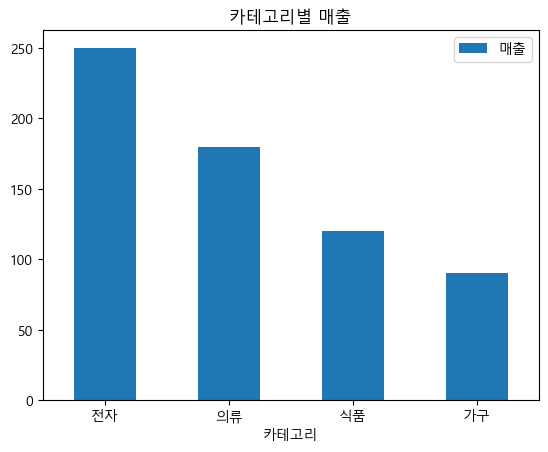

In [4]:
category_sales = pd.DataFrame({
    '카테고리' : ['전자','의류','식품','가구'],
    '매출' : [250,180,120,90]   
})

category_sales.plot(x='카테고리', y='매출', kind='bar', title="카테고리별 매출")
# x축의 글자 수평 표시
plt.xticks(rotation=0)
plt.show()

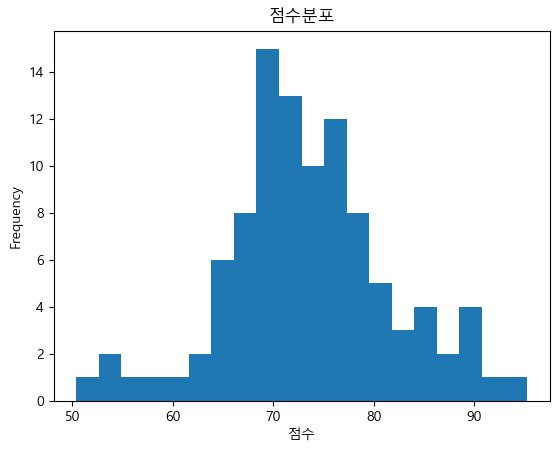

In [5]:
scores = pd.DataFrame({
    # np.random.normal(평균, 표준편차, 개수)
    '점수' : np.random.normal(75,10,100)
})

# bins
scores['점수'].plot(kind='hist', bins=20, title='점수분포')

plt.xlabel('점수')
plt.show()

## 파이 차트
 - 전체에서 각 항목이 차지하는 비율을 볼 때 사용
 - 시장 점유율처럼 비율을 한 눈에 볼 때 적합

array([<Axes: >], dtype=object)

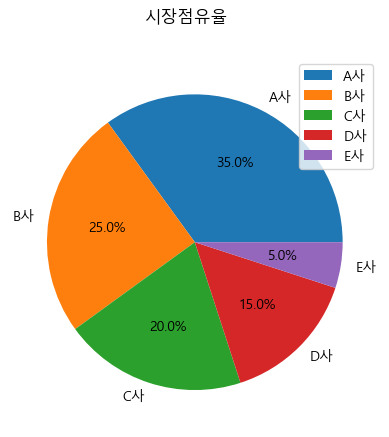

In [6]:
market_share = pd.DataFrame(
    [35,25,20,15,5], index=['A사','B사','C사','D사','E사']
)
market_share.plot(kind='pie', autopct='%.1f%%',subplots=True,title='시장점유율')

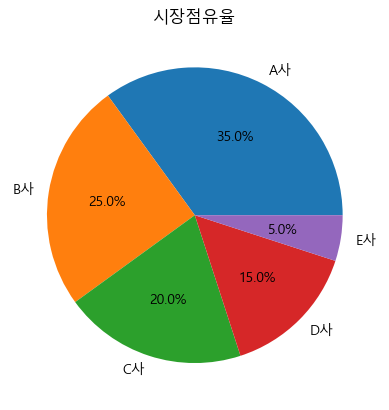

In [7]:
market_share = pd.Series(
    [35,25,20,15,5], index=['A사','B사','C사','D사','E사']
)
market_share.plot(kind='pie', autopct='%.1f%%',title='시장점유율')

plt.ylabel('')
plt.show()

## 산점도
 - 두 수치형 변수 사이의 관계를 볼 때 사용
 - 예를 들어 광고비가 증가할수록 매출도 늘어나는지? 와 같은 관계 확인

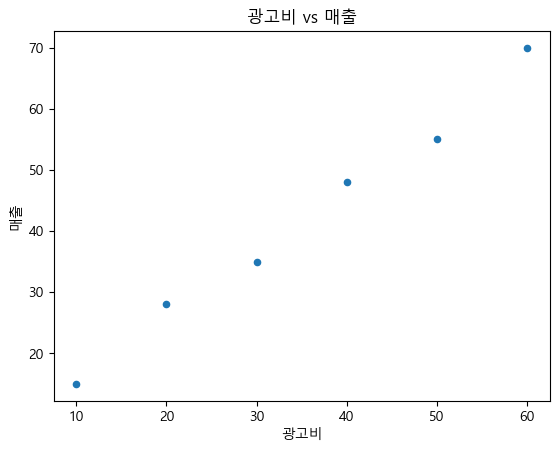

In [8]:
ad = pd.DataFrame({
    '광고비' : [10, 20, 30, 40, 50, 60],
    '매출' : [15, 28, 35, 48, 55, 70]
})

ad.plot(x='광고비', y='매출', kind='scatter', title='광고비 vs 매출')
plt.show()

## 박스 플롯
 - 분포, 중앙값, 이상치 여부를 빠르게 볼 수 있는 그래프
 - 여러 집단의 분포를 비교할 때 유용하다.

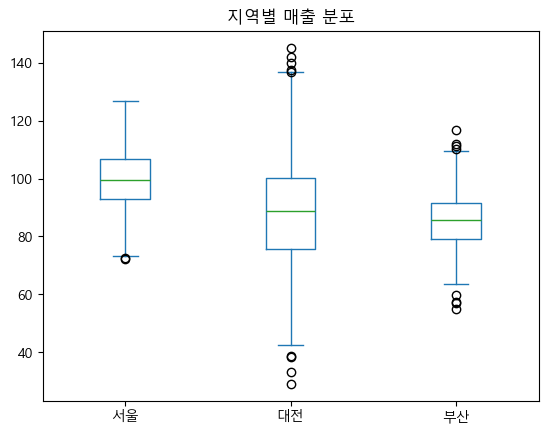

In [9]:
np.random.seed(0)
df_box = pd.DataFrame({
    # 비교적 높은 매출 + 적당한 변동
    '서울': np.random.normal(100,10,500),
    # 평균은 낮고 변동이 큼
    '대전': np.random.normal(90,20,500),
    # 평균은 낮지만 변동은 적음
    '부산': np.random.normal(85,10,500)
})

df_box.plot(kind='box',title='지역별 매출 분포')
plt.show()

## 날짜 타입 변환
날짜가 문자열 상태이면 날짜 계산이나 시계열 기능을 제대로 사용할 수 없다.
그러므로 pd.to_datetime()으로 날짜형 변환을 먼저 수행해야 한다.

In [11]:
df = pd.DataFrame({
    '날짜' : ['2026-01-15','2026-02-20','2026-03-25'],
    '매출' : [100,120,130]
})

df['날짜'] = pd.to_datetime(df['날짜'])
df.dtypes

날짜    datetime64[us]
매출             int64
dtype: object

In [ ]:
# 일정한 간격의 날짜 생성
pd.date_range(start='2026-01-01', periods=6, freq='ME') #END
pd.date_range(start='2026-01-01', periods=6, freq='MS') #START

DatetimeIndex(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01',
               '2026-05-01', '2026-06-01'],
              dtype='datetime64[us]', freq='MS')

## 날짜 속성 추출
datetie 컬럼에서는 `.dt` 접근자를 통해 년, 월, 일, 요일 같은 날짜 속성을 쉽게 꺼낼 수 있다.
월별 집계, 요일별 분석 등에 사용된다.

In [16]:
orders = pd.DataFrame({
    '주문일시' : pd.date_range('2026-01-01', periods=10, freq='D')
})

# 년, 월, 일, 요일 정보 추출
orders['년'] = orders['주문일시'].dt.year
orders['월'] = orders['주문일시'].dt.month
orders['일'] = orders['주문일시'].dt.day
orders['요일'] = orders['주문일시'].dt.dayofweek
orders['요일명'] = orders['주문일시'].dt.day_name()
orders

,주문일시,년,월,일,요일,요일명
0,2026-01-01,2026,1,1,3,Thursday
1,2026-01-02,2026,1,2,4,Friday
2,2026-01-03,2026,1,3,5,Saturday
3,2026-01-04,2026,1,4,6,Sunday
4,2026-01-05,2026,1,5,0,Monday
5,2026-01-06,2026,1,6,1,Tuesday
6,2026-01-07,2026,1,7,2,Wednesday
7,2026-01-08,2026,1,8,3,Thursday
8,2026-01-09,2026,1,9,4,Friday
9,2026-01-10,2026,1,10,5,Saturday


## 날짜 인덱스
날짜를 인덱스로 두면 날짜 범위 슬라이싱이 편해진다.

In [17]:
sales_ts = pd.DataFrame({
    '날짜' : pd.date_range('2026-01-01', periods=100, freq='D'),
    '매출' : range(100,200)
}).set_index('날짜')

sales_ts.head()

,매출
날짜,
2026-01-01,100
2026-01-02,101
2026-01-03,102
2026-01-04,103
2026-01-05,104


In [18]:
# 날짜 범위 슬라이싱
sales_ts['2026-01-15':'2026-01-20']

,매출
날짜,
2026-01-15,114
2026-01-16,115
2026-01-17,116
2026-01-18,117
2026-01-19,118
2026-01-20,119


In [ ]:
# 특정 월 선택
sales_ts

# 리샘플링
시계열 데이터를 다른 시간 단위로 다시 묶는 작업이다.
일별 데이터를 월별, 주별 데이터로 요약할 때 많이 사용한다.

In [22]:
# 일별 매출 데이터 생성
daily_sales = pd.DataFrame({
    '매출' : range(1,91)
}, index=pd.date_range('2026-01-01', periods=90, freq='D'))

daily_sales.resample('ME').sum()

,매출
2026-01-31,496
2026-02-28,1274
2026-03-31,2325


In [23]:
# 주별 평균
daily_sales.resample('W').mean()

,매출
2026-01-04,2.5
2026-01-11,8.0
2026-01-18,15.0
2026-01-25,22.0
2026-02-01,29.0
2026-02-08,36.0
2026-02-15,43.0
2026-02-22,50.0
2026-03-01,57.0
2026-03-08,64.0


## 이동 평균
이동 평균은 최근 n개 값의 평균을 구해 짧은 변동을 줄이고 전체 흐름을 더 부드럽게 보는 방법이다.

In [24]:
# 일별 매출 추이 데이터
trend = pd.DataFrame({
    '매출' : [100,120,90,130,110,140,95,150,120,160]
}, index=pd.date_range('2026-01-01', periods=10, freq='D'))

# rolling : 최근 n개 구간 기준 계산
trend['이동평균_3일'] = trend['매출'].rolling(3).mean()
trend['이동평균_5일'] = trend['매출'].rolling(5).mean()

trend

,매출,이동평균_3일,이동평균_5일
2026-01-01,100,NaN,NaN
2026-01-02,120,NaN,NaN
2026-01-03,90,103.333333,NaN
2026-01-04,130,113.333333,NaN
2026-01-05,110,110.000000,110.0
2026-01-06,140,126.666667,118.0
2026-01-07,95,115.000000,113.0
2026-01-08,150,128.333333,125.0
2026-01-09,120,121.666667,123.0
2026-01-10,160,143.333333,133.0


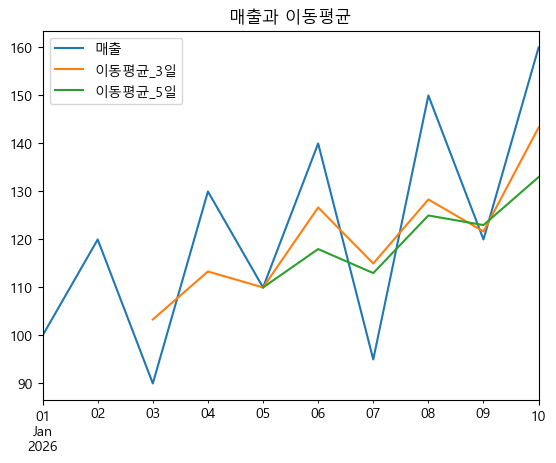

In [25]:
# 매출과 이동 평균 시각화
trend[['매출', '이동평균_3일','이동평균_5일']].plot(title='매출과 이동평균')
plt.show()

## shift / diff / pct_change
시계열에서는 이전 값과 비교하는 작업이 자주 나온다.

In [28]:
compare = pd.DataFrame({
    '매출' : [100,110,105,120,115]
}, index=pd.date_range('2026-01-01',periods=5, freq='D'))

compare['전일매출'] = compare['매출'].shift(1)  # 이전 값 밀어오기
compare['전일대비'] = compare['매출'].diff()    # 이전 값과의 차이
compare['변화율'] = compare['매출'].pct_change()*100    # 이전 값과의 차이

compare

,매출,전일매출,전일대비,변화율
2026-01-01,100,NaN,NaN,NaN
2026-01-02,110,100.0,10.0,10.000000
2026-01-03,105,110.0,-5.0,-4.545455
2026-01-04,120,105.0,15.0,14.285714
2026-01-05,115,120.0,-5.0,-4.166667


## 시계열 시각화
시계열 데이터는 원본 값만 보면 변동이 심해서 흐름이 잘 안 보일 수 있다.
따라서 이동 평균과 함께 그리면 전체 추세를 더 쉽게 파악 할 수 있다.
또한 리샘플링 후 월별 집계처럼 더 큰 단위로 요약헤서 볼 수도 있다.

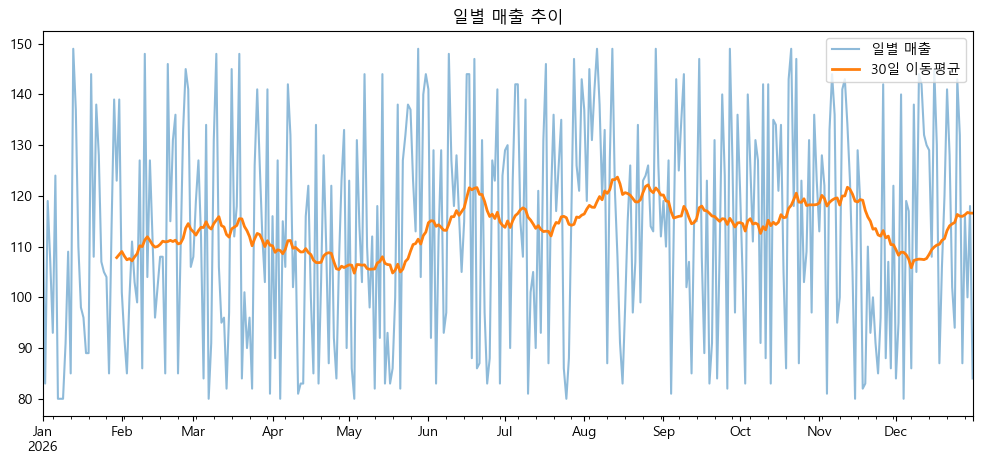

In [29]:
# 1년치 일별 매출 데이터 생성
year_sales = pd.DataFrame({
    '매출' : np.random.randint(80,150,365)
}, index=pd.date_range('2026-01-01', periods=365, freq='D'))

# 30일 이동평균 계산
year_sales['이동평균'] = year_sales['매출'].rolling(30).mean()

fig, ax = plt.subplots(figsize=(12,5))

year_sales['매출'].plot(ax=ax, alpha=0.5, label='일별 매출')
year_sales['이동평균'].plot(ax=ax, linewidth=2, label='30일 이동평균')

plt.title('일별 매출 추이')
plt.legend()    # 라벨 지정 이름 출력
plt.show()

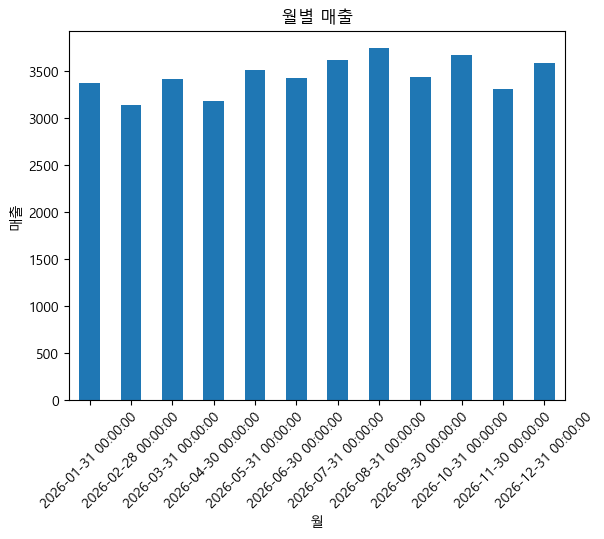

In [31]:
# 월별 집계 후 막대 그래프
monthly = year_sales.resample('ME')['매출'].sum()

monthly.plot(kind='bar', title='월별 매출')

plt.xlabel('월')
plt.ylabel('매출')

plt.xticks(rotation=45)
plt.show()